# KarmaDock prototype — results & comparison

Three pipelines on the corrected **136-complex `proto_test`**, scored by the official
`evaluation/evaluation.py` (RDKit `GetBestRMS`, symmetry-corrected, top-1), for all three
KarmaDock pose post-processing variants (**uncorrected / FF / align**).

- **P2 from scratch** — our submission model (paper 2-stage protocol, trained on `proto_train`)
- **P1 baseline** — released weights, inference only (context)
- **P3 fine-tune** *(bonus)* — released weights fine-tuned on `proto_train`

Reads the per-pipeline × per-variant eval CSVs in `../results/`, so the numbers always match
the shipped poses. Run from `notebooks/`.

In [1]:
import pandas as pd, numpy as np, os

RES = "../results"
PIPES   = {"P2 from scratch": "p2_scratch", "P1 baseline": "p1_baseline", "P3 fine-tune": "p3_finetune"}
VARIANTS = ["uncorrected", "ff", "align"]

def success2A(tag, variant):
    df = pd.read_csv(os.path.join(RES, f"{tag}_{variant}_evaluation.csv"))
    df = df[df["pose_rank"] == 1].dropna(subset=["rmsd"])
    return round(100 * df["rmsd_lt2"].mean(), 1)

table = pd.DataFrame(
    {variant: {name: success2A(tag, variant) for name, tag in PIPES.items()} for variant in VARIANTS}
)
table.columns = ["uncorrected", "FF-corrected", "align-corrected"]
print("success@2A (%)")
table

success@2A (%)


,uncorrected,FF-corrected,align-corrected
P2 from scratch,10.3,11.0,94.1
P1 baseline,80.9,78.7,95.6
P3 fine-tune,80.1,75.0,94.9


In [2]:
# uncorrected headline detail: success@2A, @1A, median RMSD
def detail(tag):
    df = pd.read_csv(os.path.join(RES, f"{tag}_uncorrected_evaluation.csv"))
    df = df[df["pose_rank"] == 1].dropna(subset=["rmsd"])
    return {"success@2A %": round(100*df["rmsd_lt2"].mean(),1),
            "success@1A %": round(100*df["rmsd_lt1"].mean(),1),
            "median RMSD": round(df["rmsd"].median(),2)}
pd.DataFrame({name: detail(tag) for name, tag in PIPES.items()}).T

,success@2A %,success@1A %,median RMSD
P2 from scratch,10.3,3.7,3.38
P1 baseline,80.9,8.1,1.45
P3 fine-tune,80.1,7.4,1.48


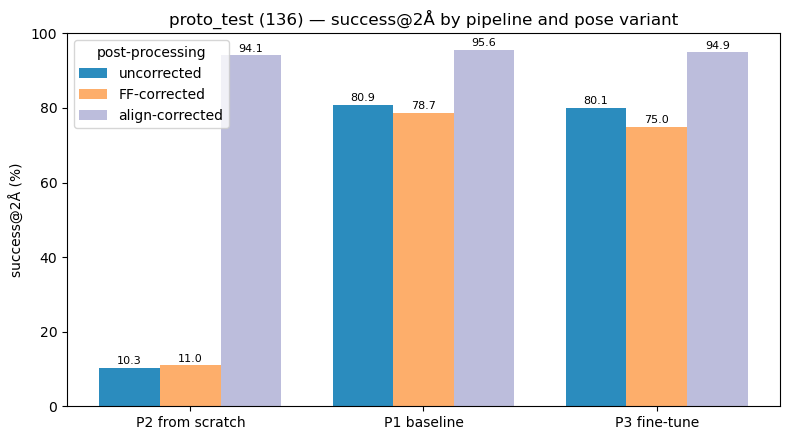

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(PIPES); x = np.arange(len(names)); w = 0.26
for i, (col, color) in enumerate(zip(["uncorrected", "FF-corrected", "align-corrected"],
                                     ["#2b8cbe", "#fdae6b", "#bcbddc"])):
    vals = [table.loc[n, col] for n in names]
    bars = ax.bar(x + (i-1)*w, vals, w, label=col, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("success@2\u00c5 (%)"); ax.set_ylim(0,100)
ax.set_title("proto_test (136) — success@2\u00c5 by pipeline and pose variant")
ax.legend(title="post-processing")
plt.tight_layout(); plt.show()

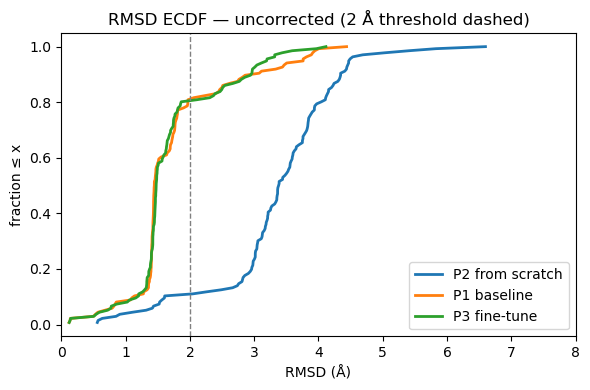

In [4]:
# RMSD ECDF (uncorrected, top-1): proportion of complexes with RMSD <= x
fig, ax = plt.subplots(figsize=(6, 4))
for name, tag in PIPES.items():
    df = pd.read_csv(os.path.join(RES, f"{tag}_uncorrected_evaluation.csv"))
    r = np.sort(df[df["pose_rank"]==1].dropna(subset=["rmsd"])["rmsd"].values)
    ax.plot(r, np.arange(1, len(r)+1)/len(r), label=name, lw=2)
ax.axvline(2.0, ls="--", c="grey", lw=1)
ax.set_xlim(0, 8); ax.set_xlabel("RMSD (\u00c5)"); ax.set_ylabel("fraction \u2264 x")
ax.set_title("RMSD ECDF — uncorrected (2 \u00c5 threshold dashed)"); ax.legend()
plt.tight_layout(); plt.show()

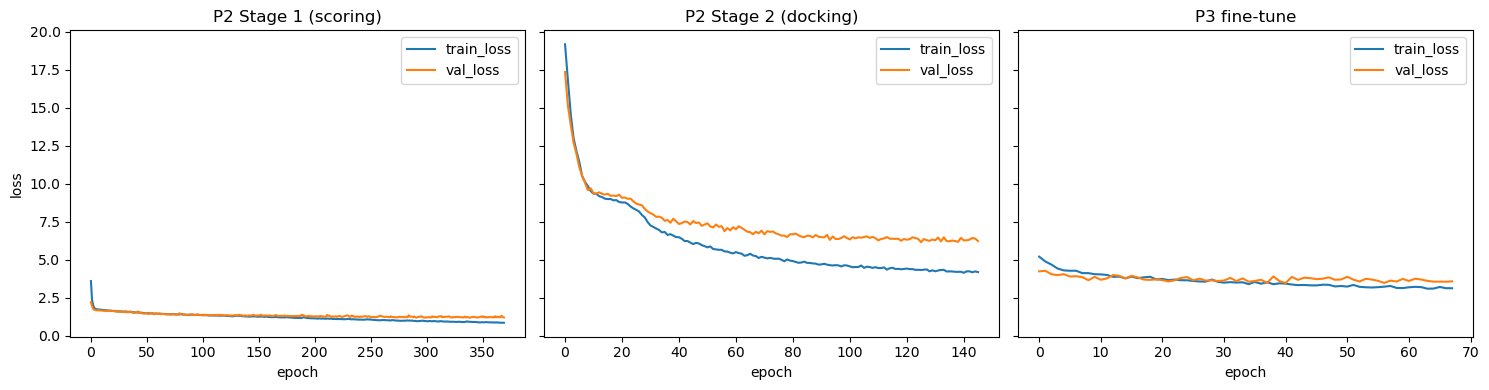

In [ ]:
# Training curves: P2 (2 stages) and P3 (single fine-tune), from ../docs/
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, (path, title) in zip(ax, [
        ("../docs/p2_stage1_train_log.csv", "P2 Stage 1 (scoring)"),
        ("../docs/p2_stage2_train_log.csv", "P2 Stage 2 (docking)"),
        ("../docs/p3_finetune_train_log.csv", "P3 fine-tune")]):
    if os.path.isfile(path):
        d = pd.read_csv(path)
        for col in ("train_loss", "val_loss"):
            if col in d.columns:
                a.plot(d.get("epoch", range(len(d))), d[col], label=col)
        a.legend()
    a.set_title(title); a.set_xlabel("epoch")
ax[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

**Notes.** The **align-corrected** variant superimposes the predicted ligand onto the reference
frame, so on this re-docking set it scores ~94–96 % for *every* pipeline — including the from-scratch
P2 that docks only ~10 % uncorrected — i.e. it reflects the reference, not docking skill. On the raw
(uncorrected) poses: P1 released weights dock well (~81 %); P2 from ~700 complexes reaches ~10 %
(pipeline correct, data-limited); P3 fine-tune preserves the baseline (~80 %).